# Causal analysis: what can the campaign data support?

Business question: is there evidence for an incremental campaign effect, and where do observational assumptions remain unverified?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,relative_week,0,1,treated_minus_control,period
0,-4,0.228014,0.234443,0.006429,pre
1,-3,0.220447,0.223160,0.002714,pre
2,-2,0.210247,0.210547,0.000300,pre
3,-1,0.201175,0.205816,0.004641,pre
4,0,0.201222,0.211002,0.009780,post
5,1,0.182374,0.196636,0.014263,post
6,2,0.172456,0.187912,0.015456,post
7,3,0.166392,0.182270,0.015878,post


,covariate,treated_mean,control_mean,standardized_mean_difference,weighting
0,pre_active_weeks,0.873966,0.859882,0.011029,unweighted
1,acquisition_channel_organic,0.383041,0.378002,0.010379,unweighted
2,acquisition_channel_paid,0.283392,0.298754,-0.033823,unweighted
3,acquisition_channel_partner,0.147933,0.149565,-0.004588,unweighted
4,acquisition_channel_referral,0.185634,0.173678,0.031147,unweighted
5,initial_segment_builder,0.296146,0.298096,-0.004268,unweighted
6,initial_segment_everyday,0.456868,0.447333,0.019159,unweighted
7,initial_segment_starter,0.246987,0.254571,-0.017498,unweighted
8,age_band_18-29,0.247162,0.255182,-0.018494,unweighted
9,age_band_30-44,0.253329,0.246627,0.015476,unweighted


,propensity_bin,treatment,customers,diagnostic,value,threshold,status
0,"(-0.001, 0.1]",0.0,0,bin_count,NaN,NaN,context
1,"(-0.001, 0.1]",1.0,0,bin_count,NaN,NaN,context
2,"(0.1, 0.2]",0.0,0,bin_count,NaN,NaN,context
3,"(0.1, 0.2]",1.0,0,bin_count,NaN,NaN,context
4,"(0.2, 0.4]",0.0,14095,bin_count,NaN,NaN,context
5,"(0.2, 0.4]",1.0,8615,bin_count,NaN,NaN,context
6,"(0.4, 0.6]",0.0,1341,bin_count,NaN,NaN,context
7,"(0.4, 0.6]",1.0,887,bin_count,NaN,NaN,context
8,"(0.6, 0.8]",0.0,5839,bin_count,NaN,NaN,context
9,"(0.6, 0.8]",1.0,19038,bin_count,NaN,NaN,context


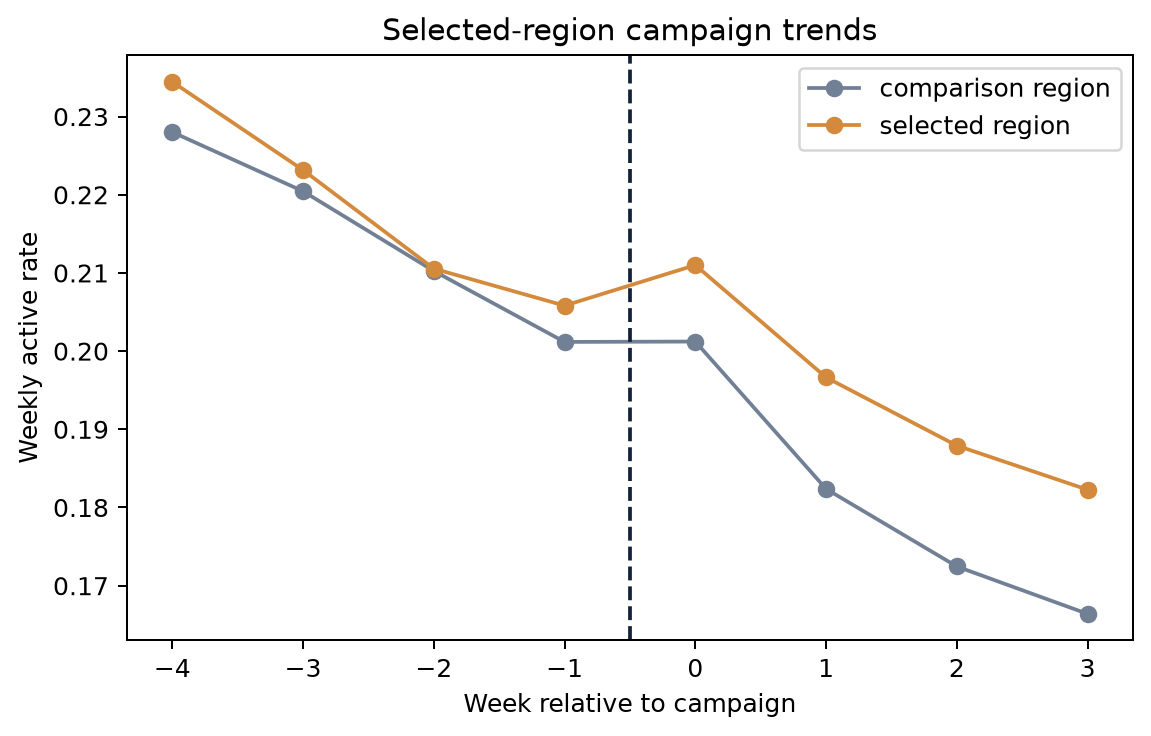

{'design': 'selected-region observational campaign; DiD plus stabilized IPTW diagnostics', 'treated_pre': 0.2184915907498248, 'treated_post': 0.1944551506657323, 'control_pre': 0.21497062279670975, 'control_post': 0.18061104582843712, 'treated_change': -0.024036440084092503, 'control_change': -0.03435957696827263, 'did_effect': 0.010323136884180129, 'iptw_did_effect': 0.009476567011063891, 'iptw_standard_error': 0.004362379314637099, 'iptw_ci_low': 0.0009263035543751776, 'iptw_ci_high': 0.018026830467752605, 'uncertainty_method': 'normal approximation on weighted customer-week means; ignores within-customer correlation', 'effective_sample_size': 42116.2497698531, 'pretrend_table': 'campaign_pretrend.csv', 'overlap_table': 'campaign_overlap.csv', 'balance_table': 'campaign_iptw_balance.csv', 'trust_status': 'pass', 'claim_scope': 'Observational estimate subject to overlap, measured balance, and parallel-trends limitations.'}


In [2]:
pretrend = table('campaign_pretrend.csv', n=12)
balance = table('campaign_iptw_balance.csv', n=12)
overlap = table('campaign_overlap.csv', n=12)
figure('campaign_weekly_trends')
print(results['causal'])

In [3]:
print('Evidence: pre-trends, balance, and overlap are diagnostics; results.json records the 2x2 contrast.')
print('Decision: use this as a diagnostic signal and design input, not as a standalone causal claim. Confirm assignment and parallel-trend assumptions before acting.')

Evidence: pre-trends, balance, and overlap are diagnostics; results.json records the 2x2 contrast.
Decision: use this as a diagnostic signal and design input, not as a standalone causal claim. Confirm assignment and parallel-trend assumptions before acting.


**Uncertainty and scope.** Uncertainty: the campaign is observational. Weighting diagnostics do not by themselves establish exchangeability, correct specification, or a causal effect.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.